In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [13]:
df = pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Desktop\california_housing_test_1.csv")
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                  27         3885             661   
1    -118.30     34.26                  43         1510             310   
2    -117.81     33.78                  27         3589             507   
3    -118.36     33.82                  28           67              15   
4    -119.67     36.33                  19         1241             244   

   population  households  median_income  median_house_value  Unnamed: 9  \
0        1537         606         6.6085              344700         NaN   
1         809         277         3.5990              176500         NaN   
2        1484         495         5.7934              270500         NaN   
3          49          11         6.1359              330000         NaN   
4         850         237         2.9375               81700         NaN   

  ocean_proximity  
0        NEAR BAY  
1        NEAR BAY  
2        NEAR BAY  
3        NEA

In [14]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   int64  
 3   total_rooms         3000 non-null   int64  
 4   total_bedrooms      3000 non-null   int64  
 5   population          3000 non-null   int64  
 6   households          3000 non-null   int64  
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   int64  
 9   Unnamed: 9          0 non-null      float64
 10  ocean_proximity     574 non-null    object 
dtypes: float64(4), int64(6), object(1)
memory usage: 257.9+ KB


longitude                0
latitude                 0
housing_median_age       0
total_rooms              0
total_bedrooms           0
population               0
households               0
median_income            0
median_house_value       0
Unnamed: 9            3000
ocean_proximity       2426
dtype: int64

In [41]:
df = df.drop("Unnamed: 9", axis=1)

In [42]:

df = df.fillna(df.mean(numeric_only=True))

df["ocean_proximity"] = df["ocean_proximity"].fillna(df["ocean_proximity"].mode()[0])

In [43]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [44]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [45]:
X = pd.get_dummies(X, drop_first=True)

In [46]:
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)



In [47]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:

Q1 = df["median_house_value"].quantile(0.25)
Q3 = df["median_house_value"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["median_house_value"] > Q1 - 1.5*IQR) &
        (df["median_house_value"] < Q3 + 1.5*IQR)]

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
y_pred = model.predict(X_test)

In [52]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 41085.789910294174
RMSE: 53022.332015364394
R2: 0.6533758095105213


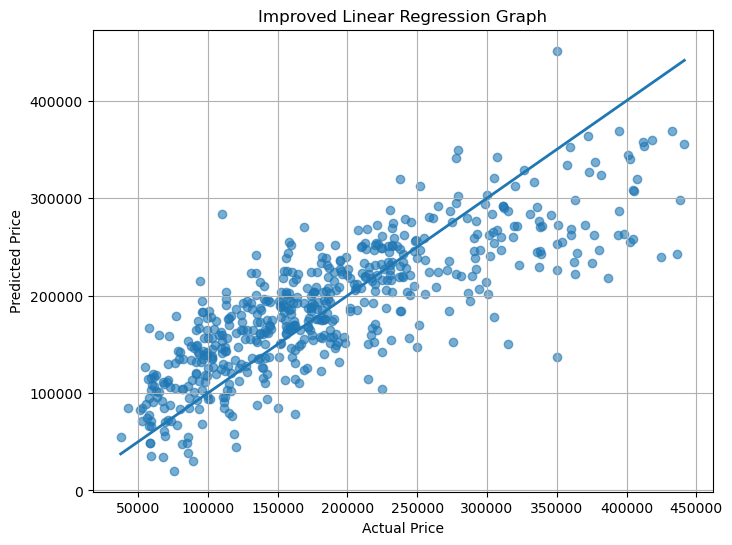

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Improved Linear Regression Graph")

plt.grid()

plt.show()

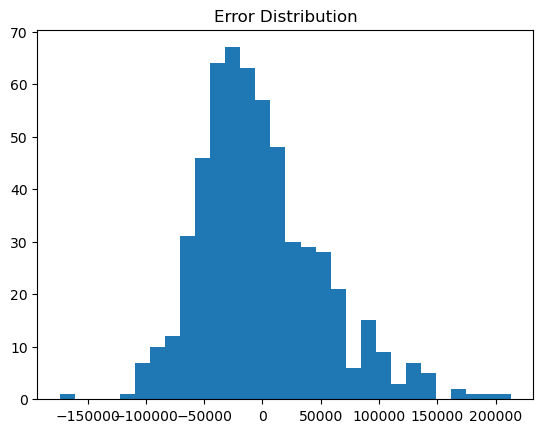

In [54]:
errors = y_test - y_pred

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.show()